In [42]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.special import factorial
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import math
from IPython.display import Latex
from scipy.integrate import nquad

import matplotlib
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import time

In [43]:
c=2.998*10**8 #in m/s

#in natural units:
v0 = 220*1000/c
v_esc = 500*1000/c 
v_E = 240*1000/c 
f=28 #coupling strength

#in eV
w_minus = 59*10**-3
w_plus = 20*10**-3
m_Si_nucleus = 2.616e10
proton_mass= 938.272e6

dm_density = 0.3e9 #eV/cm^3, plus minus 0.1
target_density = 1.307e33 #eV/cm^3 from silicon density of 2329.6 kg/m3

#in 1/eV
a_Si = 2*np.pi/(2.28*1000) #Silicon lattice constant
a0 = 2.68e-4 #Bohr radius

# Structure Factor

The equation for the Structure Factor is as follows:
\begin{aligned}
    S(q,\omega) &= \sum_{\ell,\ell'} |f|^2 C_{\ell, \ell'} \\
    &= 2|f|^2 (C_{\ell=\ell'}+C_{\ell \neq \ell'})
\end{aligned}
The diagonal term is $$ C_{\boldsymbol{\ell}d} = \frac{1}{V} e^{-2W_d(\boldsymbol{q})} \sum_{n=0} (\frac{q^2}{4m_d})^n \sum_{j=0}^n \frac{2\pi}{j!(n-j)!\omega_+^j \omega_-^{n-j}} \delta(j\omega_++(n-j)\omega_--\omega)$$ and the off-diagonal is $$C_{\boldsymbol{\ell '}\boldsymbol{\ell} d}=\frac{1}{V}e^{i\boldsymbol{q}\cdot(\boldsymbol{l}-\boldsymbol{\ell'})} e^{-2W_d(\boldsymbol{q})} \sum_{n=0}^{\omega/\omega_+} (\frac{q^2}{4m_d})^n \sum_{j=0}^n \frac{2\pi(-1)^{n-j}}{j!(n-j)!\omega_+^j \omega_-^{n-j}} \delta(j\omega_++(n-j)\omega_--\omega)$$

The function $W_d(q)$ is the Debye-Waller factor: $W_d(q)=\frac{q^2}{8m_d}(\frac{1}{\omega_1}+\frac{1}{\omega_2})$. When you integrate with $\omega$, the delta function gets removed, leaving a sum based on n and j for set values of $\omega_{n,j}$



In [44]:
"""
The Debye-Waller function for a two-site lattice
@params 
    q: the momentum transfer from dark matter to the crystal
    m: mass of nucleus in the crystal
    w1, w2: energy levels of the element
"""
def debye_waller(q, m, w1,w2):
    return q**2/(8*m)*(1/w1+1/w2)

In [45]:
"""
The diagonal terms (without the delta function) for one n,j combination
@params
    q: the momentum transfer from dark matter to the crystal
    m: mass of nucleus in the crystal
    w1, w2: energy levels of the element
    n: principle phonon number
    j: phonon mode number
    V: 1D volume (ie length) of target crystal
"""
def diagonal_C_true(q, m, w1,w2, n, j, V=a_Si):
    expDebyeWaller = np.exp(-2*debye_waller(q, m, w1,w2))
    c=expDebyeWaller/V * (q**2/(4*m))**n * 2*np.pi/(factorial(j)*factorial(n-j)*w1**j*w2**(n-j))
    return c

In [46]:
"""
The off-diagonal terms (without the delta function) for one n,j combination
@params
    q: the momentum transfer from dark matter to the crystal
    m: mass of nucleus in the crystal
    w1, w2: energy levels of the element
    n: principle phonon number
    j: phonon mode number
    V: 1D volume (ie length) of target crystal
    a: the lattice constant of the crystal
"""
def offDiagonal_C_true(q, m, w1,w2, n, j, V=a_Si, a=a_Si):
    expDebyeWaller = np.exp(-2*debye_waller(q, m, w1,w2))
    c=expDebyeWaller/V * (q**2/(4*m))**n * 2*np.pi/(factorial(j)*factorial(n-j)* w1**j * w2**(n-j))
    if (n-j)%2==1:
        c = -c
    c = c*np.cos(q*a)
    return c

In [47]:
"""
Structure Factor for one n and j pair, integrated with omega to remove the delta function
@params
    q: the momentum transfer from dark matter to the crystal
    m: mass of nucleus in the crystal
    w1, w2: energy levels of the element
    n: principle phonon number
    j: phonon mode number
    V: 1D volume (ie length) of target crystal
    a: the lattice constant of the crystal
    A: coupling strength
"""
def StructureFactor_n_j(q,m, w1, w2, n, j, V, a, A=f):
    return 2*A**2*(diagonal_C_true(q, m, w1, w2, n, j, V)
                      +offDiagonal_C_true(q, m, w1, w2, n, j, V, a))

In [48]:
"""
Structure Factor for one n, integrated with omega to remove the delta function
@params
    q: the momentum transfer from dark matter to the crystal
    m: mass of nucleus in the crystal
    w1, w2: energy levels of the element
    n: principle phonon number
    V: 1D volume (ie length) of target crystal
    a: the lattice constant of the crystal
    A: coupling strength
"""
def StructureFactor_n(q, m, w1,w2, n, V, a, A=f):
    return sum([2*A**2*(diagonal_C_true(q, m, w1,w2, n, j, V)
                        +offDiagonal_C_true(q, m, w1,w2, n, j, V, a)) for j in range(n+1)] )

In [49]:
"""
Diagonal Structure Factor for one n, integrated with omega to remove the delta function
@params
    q: the momentum transfer from dark matter to the crystal
    m: mass of nucleus in the crystal
    w1, w2: energy levels of the element
    n: principle phonon number
    V: 1D volume (ie length) of target crystal
    A: coupling strength
"""
def StructureFactor_diag(q, m, w1,w2, n, V, A):
    return sum([2*A**2* diagonal_C_true(q, m, w1,w2, n, j, V) for j in range(n+1)] )

In [50]:
#Calculate the structure factor integrated wrt omega for first 4 phonon numbers
q_range = 10**np.linspace(-1, np.log10(300), 3000) #keV
S_int_w = [[StructureFactor_n(q*1000, m_Si_nucleus, w_plus, w_minus, n, 1, a_Si, 1) for q in q_range] 
           for n in range(1,5)] #structure factor
S_int_diag= [[StructureFactor_diag(q*1000, m_Si_nucleus, w_plus, w_minus, n, 1, 1) for q in q_range] 
            for n in range(1,5)] #diagonal portion for reference

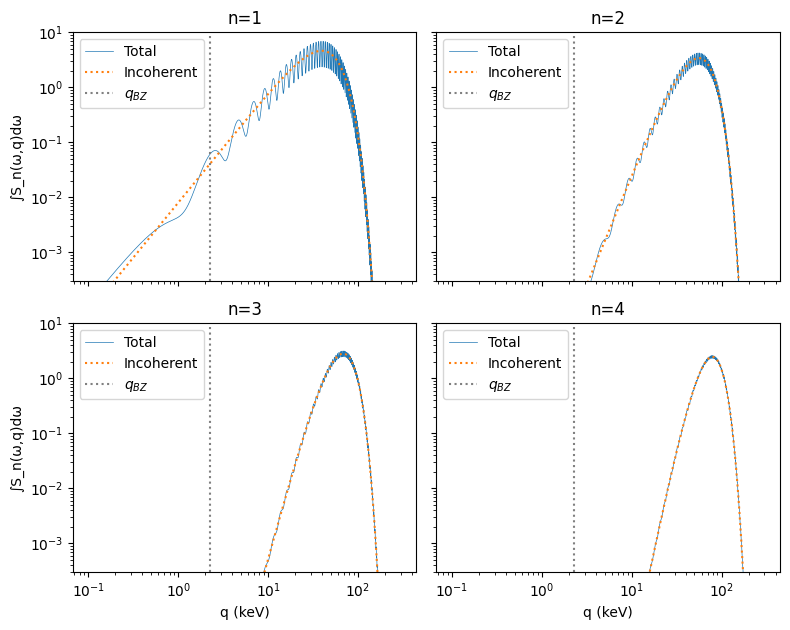

In [53]:
fig, axs = plt.subplots(2, 2, sharey=True, figsize=(8, 6.4))
for n in range(4):
    axs[int(n/2), n%2].plot(q_range, S_int_w[n], linewidth=0.5, label = "Total")
    axs[int(n/2), n%2].plot(q_range, S_int_diag[n], linewidth=1.5, linestyle = ":", label="Incoherent")
    axs[int((n)/2), n%2].set_xscale('log')
    axs[int((n)/2), n%2].set_title("n="+str(n+1))
    axs[int((n)/2), n%2].axvline(2.28, color="gray", linestyle=":", label=r"$q_{BZ}$")
    axs[int((n)/2), n%2].legend()
    axs[int((n)/2), n%2].set_ylim(3e-4,10)
for ax in axs.flat:
    ax.set(xlabel='q (keV)', ylabel='∫S_n(ω,q)dω')
for ax in axs.flat:
    ax.label_outer()
plt.yscale('log')
plt.tight_layout()
plt.show()

We can also make a color graph that shows the structure factor as a function of both energy and momentum transfer

In [11]:
"""
Find the possible combinations of n and j that give energies lower or equal to the maximum energy transfer
@params:
    omega: energy transfer from dark matter to crystal
    w1, w2: energy levels of the element
@returns:
    a list of paired principle phonon numbers and phonon modes
"""
def get_possible_n_j(omega, w1 = w_plus,w2=w_minus): 
    maxN = int(omega/w1)
    pairs = [(n, j) for n in range(1,maxN + 1) for j in range(n + 1)]
    pairs_array = np.array(pairs)
    n_values = pairs_array[:, 0]
    j_values = pairs_array[:, 1]
    condition = (j_values * w1 + (n_values - j_values) * w2) <= omega
    filtered_pairs = pairs_array[condition]
    return filtered_pairs

"""
Find all energies from the n,j pair
@params:
    n_j_pairs: a list of paired principle phonon numbers and phonon modes
    w1, w2: energy levels of the element
@ returns:
    List of all possible energies
"""
def get_possible_omega(n_j_pairs, w1 = w_plus,w2=w_minus):
    n_values = n_j_pairs[:, 0]
    j_values = n_j_pairs[:, 1]
    return j_values * w1 + (n_values - j_values) * w2

"""
Removes degenerate energies
@params:
    omega_list: list of energies
    s_list: list of structure factors
@returns:
    List of unique energies
    Corresponding list of structure factors
"""
def remove_degeneracy(omega_list, s_list):
    unique_omega = np.unique(omega_list)
    unique_s = []
    for val in unique_omega:
        indices = np.where(omega_list == val)[0]
        unique_s.append(np.sum(s_list[indices], axis=0))
    return unique_omega, np.array(unique_s)

In [12]:
#We get all the pairs of n,j and corresponding energies up to the maximum energy, which we set to be 300 meV
maxOmega = 0.300 #eV
n_j_list = get_possible_n_j(maxOmega)
possible_omega_list = get_possible_omega(n_j_list)

qbz = 2*np.pi / a_Si #First Brillouin zone of the Silicon lattice

#Create the momentum range for the graph
log_q_list = np.linspace(0, np.log10(400), 10000)
q_list = 10**log_q_list # keV


#Create the diagonal and corrected structure factors for each energy and momentum
s_list = []
s_diag_list = []
for n_j_pairs in n_j_list: #iterate for each n,j pair
    s_list.append(2*f**2 * diagonal_C_true(q_list*1000, m_Si_nucleus, w_plus,w_minus, n_j_pairs[0],n_j_pairs[1])+
                  2*f**2 * offDiagonal_C_true(q_list*1000, m_Si_nucleus, w_plus,w_minus, n_j_pairs[0],n_j_pairs[1]))
    s_diag_list.append(2*f**2 * diagonal_C_true(q_list*1000, m_Si_nucleus, w_plus,w_minus, n_j_pairs[0],n_j_pairs[1]))
#remove the degeneracies in the lists
clean_omega_list, clean_s_list = remove_degeneracy(possible_omega_list, np.array(s_list))
clean_omega_list, clean_s_diag_list = remove_degeneracy(possible_omega_list, np.array(s_diag_list))

#Create the omega range for the plot.  There are 4000 points
omega_list = np.linspace(0, maxOmega, 4000) # eV

#Make a matrix of structure factors, where the horizontal axis is momentum transfer and the vertical is energy
s_list_plot = np.zeros((len(omega_list), len(log_q_list)))
s_diag_list_plot = np.zeros((len(omega_list), len(log_q_list)))
for i, w in enumerate(clean_omega_list):
    ind = np.where((omega_list > w - 0.0006) & (omega_list < w + 0.0006))[0] #round the calculated energies to the set energy points
    s_list_plot[ind, :] = clean_s_list[i]
    s_diag_list_plot[ind, :] = clean_s_diag_list[i]


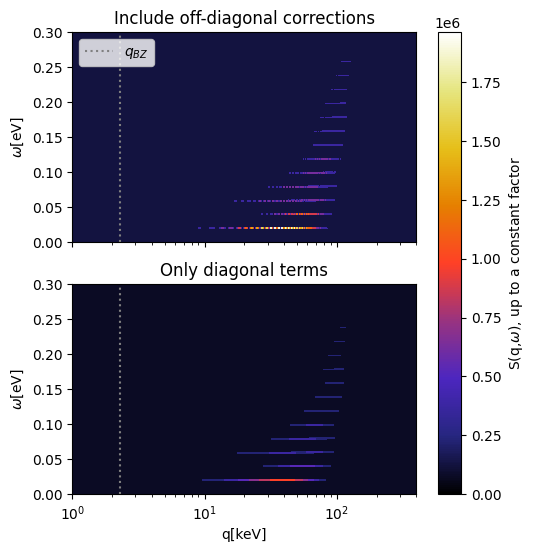

In [13]:
#Graphing the structure factor colorplot
X, Y = np.meshgrid(q_list,omega_list)
fig, axes = plt.subplots(nrows=2, figsize=(4,6),sharey=True,sharex=True)
cmap = matplotlib.colormaps.get_cmap('CMRmap')
normalizer = Normalize(0, np.max(s_list_plot))
im = cm.ScalarMappable(norm=normalizer, cmap='CMRmap')

axes[0].contourf(X, Y, s_list_plot,cmap='CMRmap',norm=normalizer)
axes[0].axvline(qbz/1000, linestyle=':', color='gray',label=r'$q_{BZ}$') #Brillouin zone in keV
axes[0].set_xscale('log')
axes[0].set_title('Include off-diagonal corrections')
axes[0].set_ylabel('$\omega$[eV]')
axes[0].legend(loc='upper left')


axes[1].contourf(X, Y, s_diag_list_plot,cmap='CMRmap', norm=normalizer)
axes[1].axvline(2*np.pi/(a_Si*1000), linestyle=':', color='gray')
axes[1].set_xscale('log')
axes[1].set_title('Only diagonal terms')
axes[1].set_xlabel('q[keV]')
axes[1].set_ylabel('$\omega$[eV]')

fig.subplots_adjust(right=1.2, wspace=0)
cbar = fig.colorbar(im, ax=axes.ravel().tolist())
cbar.set_label(r'S(q,$\omega$), up to a constant factor', )

plt.show()

# Differential Momentum Spectrum
We will now find the derivative of the scattering rate with respect to q.  The equation for the scattering rate is $$ R_\chi = \frac{\rho_\chi}{\rho_T m_\chi} \int \frac{dq \, q}{(2\pi)^2} \, \cdot \frac{\pi \sigma}{\mu_\chi^2} \int d\omega \, \eta(v_{min}(q,\omega)) \cdot S(q,\omega)$$ 

This makes the derivative with respect to q: $$\frac{\partial R}{\partial q} = \frac{\rho_\chi}{\rho_T m_\chi} \frac{1}{4\pi} \, \cdot \frac{\sigma}{\mu_\chi^2} q \int d\omega \, \eta(v_{min}(q,\omega)) \cdot S(q,\omega)=\frac{\rho_\chi}{\rho_T m_\chi} \frac{1}{4\pi} \, \cdot \frac{\sigma}{\mu_\chi^2} q \sum_n \sum_{j=0}^n \eta(v_{min}(q,\omega_{n,j})) \cdot S_{n,j}(q)$$

In [14]:
"""
This gives the two-body reduced mass equation
@params:
    m1, m2: masses of the two bodies
@returns: Effective mass of the two bodies
"""
def reducedMass(m1, m2):
    return m1*m2/(m1+m2)

First, we code the inverse mean function $\eta(v_{min})$

In [15]:
ratio=v_esc/v0
N0 = v0**3*np.pi*(np.sqrt(np.pi)*scipy.special.erf(ratio)-2*ratio*np.exp(-ratio**2))

"""
Helper function 1 and 2 for finding the output of the inverse mean function.
@Params:
    v_min: input minimum speed for dark matter
    m_chi: mass of dark matter
    const: scaling value for graphing.  As a default, it gives the true scale of the equation
"""
def inverseMeanFunction_sol1(v_min, const):
    summ = np.sqrt(np.pi)*v0*(scipy.special.erf((v_min+v_E)/v0)-scipy.special.erf((v_min-v_E)/v0))
    summ -= 4*np.exp(-v_esc**2/v0**2)*v_E
    return summ*const
def inverseMeanFunction_sol2(v_min, const):
    summ = np.sqrt(np.pi)*v0*(scipy.special.erf(v_esc/v0)-scipy.special.erf((v_min-v_E)/v0))
    summ -= 2*np.exp(-v_esc**2/v0**2)*(v_esc-v_min+v_E)
    return summ*const


"""
Returns the inverse mean value for any given v_min.  
@Params:
    v_min: input minimum speed for dark matter
    m_chi: mass of dark matter
    const: scaling value for graphing.  As a default, it gives the true scale of the equation
"""
def inverseMeanFunction(v_min, const = v0**2*np.pi/(2*v_E*N0)):
    if v_min>v_esc+v_E:
        return 0
    elif v_min>v_esc-v_E:
        return inverseMeanFunction_sol2(v_min,const)
    else: 
        return inverseMeanFunction_sol1(v_min,const)

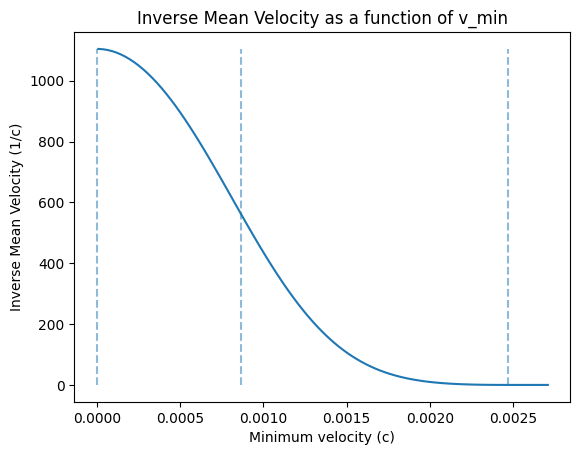

In [16]:
#Graphing the inverse mean as a function of the minimum velocity

vmin_range = np.linspace(0.01*v_E, v_esc+v_E*1.3, 100)
imf_vmin = [inverseMeanFunction(v) for v in vmin_range]

plt.plot(vmin_range, imf_vmin)
plt.vlines([0, v_esc-v_E, v_esc+v_E], 0,max(imf_vmin), linestyles="dashed", alpha=0.5)
plt.title("Inverse Mean Velocity as a function of v_min")
plt.ylabel("Inverse Mean Velocity (1/c)")
plt.xlabel("Minimum velocity (c)")
plt.show()

In [17]:
"""
Find the minumum speed of dark matter
@params: 
    q: momentum transfer
    m_chi: mass of a dark matter particle
    w: energy transfer
@returns: minimum velocity of dark matter to hit crystal
"""
def v_min(q,m_chi, w): 
    return w/q+q/(2*m_chi)

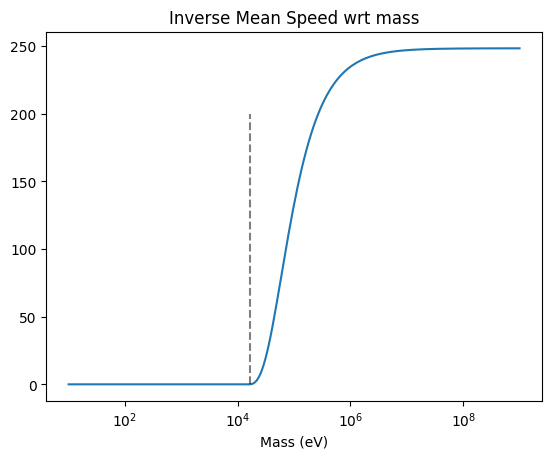

In [18]:
#Graphing the inverse mean speed to check that the boundary condition is correct
mass_range = 10**np.linspace(1, 9, 200) #in eV
plt.plot(mass_range, [inverseMeanFunction(v_min(m*(v_esc+v_E), m, 50e-3)) for m in mass_range])
plt.vlines(100e-3/(v_esc+v_E)**2, 0, 200, colors="black", alpha=0.5, linestyle="dashed")
plt.xscale("log")
plt.title("Inverse Mean Speed wrt mass")
plt.xlabel("Mass (eV)")
plt.show()

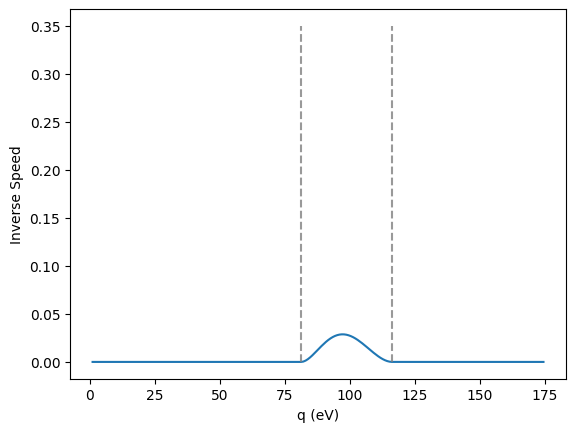

In [19]:
#Graph of the inverse speed wrt to q
v_val = v_esc+v_E #Created for simplicity
Mass_DM = 40e3
root= Mass_DM**2 * v_val**2  -  4*w_minus*Mass_DM
q_range = np.linspace(1, (Mass_DM*v_val+np.sqrt(root))*1.5,200)


plt.plot(q_range,[inverseMeanFunction(v_min(q, Mass_DM, 2*w_minus)) for q in q_range])
plt.vlines([Mass_DM*v_val-np.sqrt(root), Mass_DM*v_val+np.sqrt(root)], 0, 0.35, alpha=0.8, color="grey", linestyle="dashed")

plt.ylabel("Inverse Speed")
plt.xlabel("q (eV)")

plt.show()


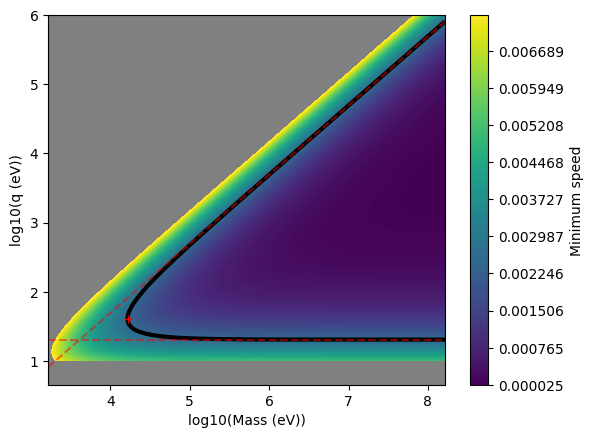

In [20]:
#Colorgraph of the minimum speed with respect to mass and momentum transfer.  In log scale.  
#The dotted lines represent the boundary conditions for large masses, 
#while the black line represents the actual boundary conditions

wcurr=50e-3 #The current energy value
m_cross = wcurr*2/v_val**2 #The minimum mass
mass_range = np.linspace(np.log10(m_cross)-1, np.log10(m_cross)+4, 200) #log of the mass range

q_range=np.linspace(1,6,300) #log of the momentum transfer range

#Finding the corresponding minimum speeds for each point on the mass/momentum graph
vmin_plot = np.zeros((len(q_range), len(mass_range)))
for rw in range(len(q_range)):
    for cl in range(len(mass_range)):
        vmin_plot[rw,cl] = v_min(10**q_range[rw],10**mass_range[cl], wcurr)

#Creating the graph, with limits to the contour
X, Y = np.meshgrid(mass_range,q_range)
fig1, ax2 = plt.subplots()
ax2.set_facecolor("grey")
cs = ax2.contourf(X,Y,vmin_plot, levels=np.linspace(v_val/100, v_val*3, 300))
ax2.contour(X,Y, vmin_plot, [v_val], colors=("black",), linewidths=(3,))
cbar = fig1.colorbar(cs)
cbar.ax.set_ylabel("Minimum speed")
plt.xlabel("log10(Mass (eV))")
plt.ylabel("log10(q (eV))")
plt.plot(np.log10(wcurr*2/v_val**2),np.log10(2*wcurr/v_val), 'r+')
plt.hlines([np.log10(wcurr/v_val)], min(mass_range),max(mass_range),color="red", linestyle="dashed", alpha=0.5,label=r"$q_{min}$ for large $m_\chi$")
plt.plot(mass_range, [np.log10(2*10**m*v_val) for m in mass_range], color="red", linestyle="dashed", alpha=0.5)
plt.show()

Once we have the mean velocity equation, we can then find the derivative of the scattering rate with respect to q and integrate to find the scattering rate for one type of phonon

In [21]:
"""
This gives the derivative of the scattering rate with respect to the momentum transfer
@params:
    q: momentum transfer
    m_chi: mass of dark matter
    n: principle phonon number
    j: phonon mode number
    sigma: cross section
    A: coupling strength
    V: volume of the crystal
    a: lattice constant of the crystal
@returns:
    dR/dq
"""
def R_deriv_q_onePhonon(q, m_chi, n, j,sigma=1, A=f, V=a_Si, a=a_Si): 
    sFactor = StructureFactor_n_j(q,m_Si_nucleus, w_plus, w_minus, n, j, V, a, A)
    reducMass = reducedMass(m_chi, proton_mass)
    front_terms = dm_density*sigma/(4*np.pi*target_density*m_chi* reducMass**2)
    w_curr=n*w_minus+j*(w_plus-w_minus)
    return front_terms*q*inverseMeanFunction(v_min(q,m_chi, w_curr))*sFactor*3.15576e7 *1000/(6.626e-60*4.1356**2)*(2*np.pi)**3

In [22]:
"""
This gives the derivative of the scattering rate with respect to the momentum transfer for the diagonal portion
@params:
    q: momentum transfer
    m_chi: mass of dark matter
    n: principle phonon number
    j: phonon mode number
    sigma: cross section
    A: coupling strength
    V: volume of the crystal
    a: lattice constant of the crystal
@returns:
    dR/dq
"""
def R_deriv_q_diag_n(q, m_chi, n,j, sigma=1, A=f, V=a_Si, a=a_Si): 
    sFactor= 2*A**2* diagonal_C_true(q, m_Si_nucleus, w_plus,w_minus, n, j, V)
    reducMass = reducedMass(m_chi, proton_mass)
    front_terms = dm_density*sigma/(4*np.pi*target_density*m_chi* reducMass**2)
    w_curr=n*w_minus+j*(w_plus-w_minus)
    return front_terms*q*inverseMeanFunction(v_min(q,m_chi, w_curr))*sFactor*3.15576e7 *1000/(6.626e-60*4.1356**2)*(2*np.pi)**3

50000.0


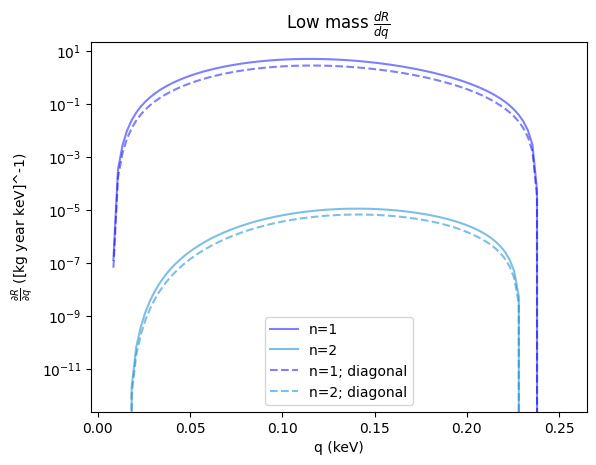

In [23]:
#Creating a graph of dR/dq for low masses.  Only n=1 and n=2 produce nonzero values
#The value of the energy used for the root is the lowest potential energy value

#Mass_DM = 4*w_minus/v_val**2 +5
Mass_DM = 50e3
print(Mass_DM)
root= Mass_DM**2 * v_val**2  -  2*(w_minus-w_plus)*Mass_DM
q_range = np.linspace((Mass_DM*v_val-np.sqrt(root))/2, (Mass_DM*v_val+np.sqrt(root))*1.1,100)


deriv = [[sum([R_deriv_q_onePhonon(q,Mass_DM, n,j, sigma=1e-42, V=(a_Si**3)/4) for j in range(n+1)]) 
          for q in q_range] for n in range(1,3)]

deriv_diag = [[sum([R_deriv_q_diag_n(q,Mass_DM, n,j, sigma=1e-42, V=(a_Si**3)/4) for j in range(n+1)]) 
          for q in q_range] for n in range(1,3)]

plt.plot(q_range/1000, deriv[0], color="blue", label="n=1", alpha=0.5)
plt.plot(q_range/1000, deriv[1], color=(0,0.5, 0.8), label="n=2", alpha=0.5)

plt.plot(q_range/1000, deriv_diag[0], color="blue", label="n=1; diagonal", linestyle="dashed", alpha=0.5)
plt.plot(q_range/1000, deriv_diag[1], color=(0,0.5, 0.8), label="n=2; diagonal", linestyle="dashed", alpha=0.5)

'''inverse_mean = [[[inverseMeanFunction(v_min(q,Mass_DM, n*w_minus+j*(w_plus-w_minus))) for q in q_range] for j in range(n+1)] for n in range(1,3)]
colors=["red", "orange"]
for phonon_num in range(2):
    for phonon in inverse_mean[phonon_num]:
        plt.plot(q_range/1000, phonon, color=colors[phonon_num])'''
plt.yscale("log")
plt.xlabel("q (keV)")
plt.legend()
plt.ylabel(r"$\frac{\partial R}{\partial q}$ ([kg year keV]^-1)")
plt.title(r"Low mass $\frac{dR}{dq}$")
plt.show()

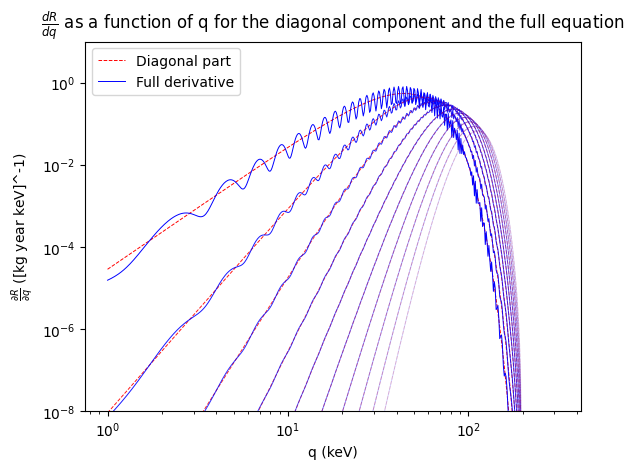

In [24]:
#Finds the derivative of the scattering rate with respect to momentum transfer
q_range = np.linspace(3,5.5,500)
q_range = 10**q_range
Mass_DM = 40e6
deriv = [[sum([R_deriv_q_onePhonon(q,Mass_DM, n,j, sigma=1e-42, V=(a_Si**3)/4) for j in range(n+1)]) 
          for q in q_range] for n in range(1,11)]
deriv_diag = [[sum([R_deriv_q_diag_n(q, Mass_DM, n,j, sigma=1e-42, V=a_Si**3/4) for j in range(n+1)]
                               ) for q in q_range] for n in range(1,11)]

#Graphing the derivative dR/dq for different phonon numbers
for i in range(10):
    plt.plot(q_range/1000, deriv_diag[i], color="red", alpha=(11-i)/11, linewidth=0.7, linestyle="dashed")
    plt.plot(q_range/1000, deriv[i], color="blue", alpha=(11-i)/11, linewidth=0.7)
plt.yscale("log")
plt.xscale("log")
plt.xlabel("q (keV)")
plt.ylabel(r"$\frac{\partial R}{\partial q}$ ([kg year keV]^-1)")
plt.ylim([1e-8,10])
plt.legend(["Diagonal part", "Full derivative"])
plt.title(r"$\frac{dR}{dq}$ as a function of q for the diagonal component and the full equation")
plt.show()

In [25]:
"""
Sums up all dR/dq from a threshold energy to a high principal phonon number
@params: 
    q: momentum transfer
    m_chi: dark matter mass
    w_mini: minimum energy
    w_max: maximum energy
    sigma: cross-sectional area
    A: coupling constant
    V: volume of crystal
    a: lattice spacing
"""
def R_deriv_q_combo(q,m_chi, w_mini,w_max=0.1,sigma=1, A=f, V=(a_Si**3)/4, a=a_Si):
    n_min = max(math.ceil(w_mini/w_minus), 1)
    n_max = int(min(w_max, m_chi*(v_esc+v_E)**2/2)/w_plus)
    if n_min>n_max:
        #return None
        return 0
    tot = sum(sum(R_deriv_q_onePhonon(q, m_chi, n, j, sigma, A, V, a) 
                  for j in range(max([0, math.ceil((n*w_minus-w_max)/(w_minus-w_plus))]), min([math.floor((n*w_minus-w_mini)/(w_minus-w_plus)),n])+1)) for n in range(n_min, n_max+1))
    return tot

In [26]:
#R_deriv_q_diag_n(q, m_chi, n,j, sigma=1, A=f, V=a_Si, a=a_Si):
"""
Sums up all diagonal dR/dq from a threshold energy to a high principal phonon number
@params: 
    q: momentum transfer
    m_chi: dark matter mass
    w_mini: minimum energy
    w_max: maximum energy
    sigma: cross-sectional area
    A: coupling constant
    V: volume of crystal
    a: lattice spacing
"""
def Rdiag_deriv_q_combo(q,m_chi, w_mini,w_max=0.1,sigma=1, A=f, V=(a_Si**3)/4, a=a_Si):
    n_min = max(math.ceil(w_mini/w_minus), 1)
    n_max = int(min(w_max, m_chi*(v_esc+v_E)**2/2)/w_plus)
    if n_min>n_max:
        #return None
        return 0
    tot = sum(sum(R_deriv_q_diag_n(q, m_chi, n, j, sigma, A, V, a) 
                  for j in range(max([0, int((n*w_minus-w_max)/(w_minus-w_plus))]), min([math.floor((n*w_minus-w_mini)/(w_minus-w_plus)),n])+1)) for n in range(n_min, n_max+1))
    return tot

In [27]:
ThomasFermi = 0.37 *a0
def Screening(q):
    return (ThomasFermi*q)**4/(1+(ThomasFermi*q)**2)**2
def R_q_func_screen(q, m_chi, w_mini,w_max, sigma, A, V, a):
    return R_deriv_q_combo(q,m_chi, w_mini,w_max, sigma, A, V, a) *Screening(q)

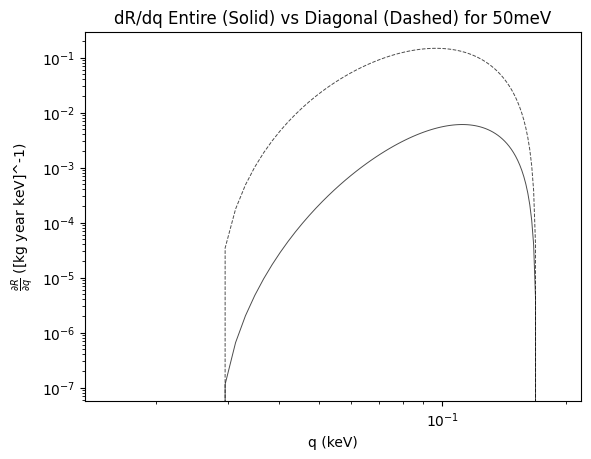

In [28]:
#Comparison of dR/dq for incoherent approx. vs entire calculation
Mass_DM = 40e3
root= Mass_DM**2 * v_val**2  -  2*Mass_DM*50e-3
q_range = np.linspace((Mass_DM*v_val-np.sqrt(root))/1.5, (Mass_DM*v_val+np.sqrt(root))*1.1,100)

deriv_combo = [R_deriv_q_combo(q, Mass_DM, 50e-3,sigma=1e-42,w_max=0.5) for q in q_range]
plt.plot(q_range/1000, deriv_combo, color="black", alpha=0.7, linewidth=0.7, label="Sum with energy cutoff")
deriv_combo_diag = [Rdiag_deriv_q_combo(q, Mass_DM, 50e-3,sigma=1e-42,w_max=0.5) for q in q_range]
plt.plot(q_range/1000, deriv_combo_diag, color="black", alpha=0.7, linewidth=0.7, linestyle="dashed")

plt.yscale("log")
plt.xscale("log")
plt.xlabel("q (keV)")
plt.ylabel(r"$\frac{\partial R}{\partial q}$ ([kg year keV]^-1)")
plt.title("dR/dq Entire (Solid) vs Diagonal (Dashed) for 50meV")
plt.show()



Mass_DM = 40e6
q_range = np.linspace(3,5.5,500)
q_range = 10**q_range

In [29]:
#creates and times the combined dR/dq
start = time.time()
Mass_DM = 40e6
deriv_combo = [R_deriv_q_combo(q, Mass_DM, w_plus,sigma=1e-42,w_max=1) for q in q_range]
print(time.time()-start)

3.2276577949523926


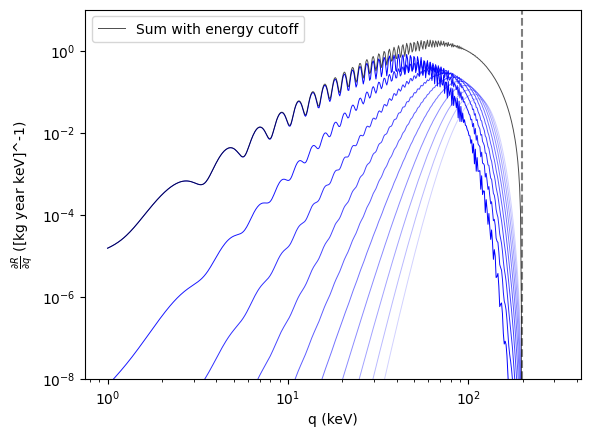

In [30]:
#dR/dq for n from 1 to 10 and the combined scattering for a scattering maximum of 1eV
for i in range(10):
    plt.plot(q_range/1000, deriv[i], color="blue", alpha=(11-i)/11, linewidth=0.7)
plt.plot(q_range/1000, deriv_combo, color="black", alpha=0.7, linewidth=0.7, label="Sum with energy cutoff")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("q (keV)")
plt.ylabel(r"$\frac{\partial R}{\partial q}$ ([kg year keV]^-1)")
plt.ylim([1e-8,10])
plt.vlines((Mass_DM*(v_esc+v_E)*2)/1000, 1e-8, 10, colors="black", alpha=0.5, linestyle="dashed")
plt.legend()
plt.show()

In [31]:
Z=f
"""
R over q from 2011.09477 paper
"""
NT = 6.022e23/(28.085e-3)
def R_over_q_one_n(q,n, m_chi, N_T, sigma, w0=30e-3):
    q0 = np.sqrt(2*m_Si_nucleus*w0)
    reducedmass = reducedMass(m_chi, proton_mass) #in eV
    constants = N_T*dm_density/m_chi * Z**2*sigma/(2*reducedmass**2)
    inside_summation = (q/math.factorial(n)) 
    inside_summation*=(q/q0)**(2*n)*np.exp(-(q/q0)**2)*inverseMeanFunction(v_min(q,m_chi,n*w0))
    return constants*inside_summation *2.998e10 *3.15576e7 *1000 #convertion to [kg year keV]^-1

def R_over_q_combo(q,m_chi, w_mini,w_max=0.1,N_T=NT, sigma=1,  w0=30e-3):
    n_min = max(int(w_mini/w0),1)
    n_max = int(w_max/w0)
    arr = []
    for n in range(n_min, n_max):
        arr.append(R_over_q_one_n(q,n, m_chi, N_T, sigma))
    return sum(arr)*Screening(q)

mX=40e6

#dR/dq from Poisson paper for several principle phonon numbers
deriv2 = [[R_over_q_one_n(q,n,mX,NT, 1e-42, 30e-3) for q in q_range] for n in range(1,11)]

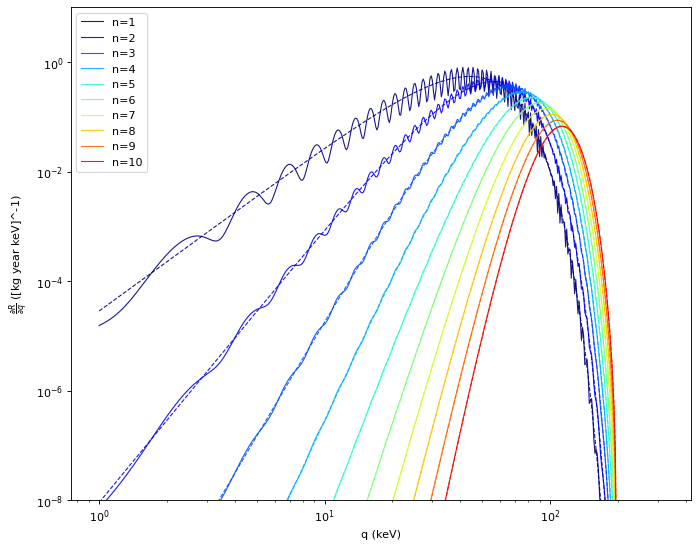

In [32]:
#Comparison of our dR/dq and the one from the 2011 paper
plt.figure(figsize=(10,8), dpi=80)
colors = plt.cm.jet(np.linspace(0,1,11))
for i in range(10):
    plt.plot(q_range/1000, deriv[i], color=colors[i], alpha=0.9, linewidth=1, label="n="+str(i+1))
    plt.plot(q_range/1000, deriv2[i], color=colors[i], alpha=0.9, linewidth=1, linestyle="dashed")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("q (keV)")
plt.ylabel(r"$\frac{\partial R}{\partial q}$ ([kg year keV]^-1)")
plt.ylim([1e-8,10])
plt.legend(loc="upper left")
plt.show()

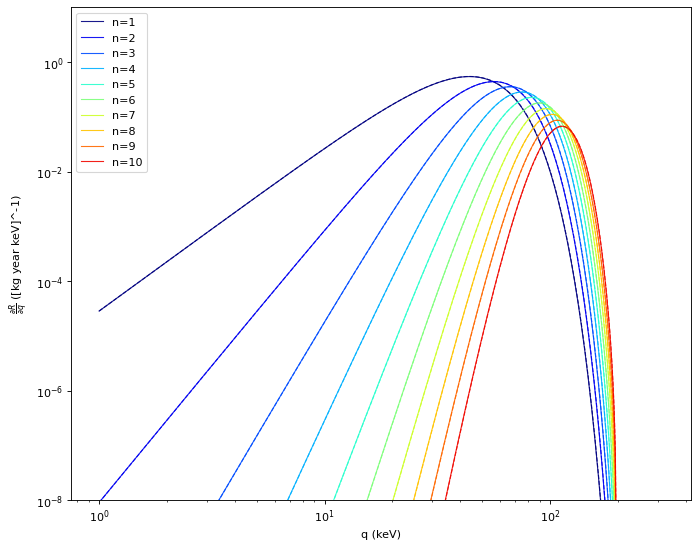

In [33]:
#Comparison of dR/dq for the diagonal portion of our calculations with dR/dq from the Poisson paper
plt.figure(figsize=(10,8), dpi=80)
colors = plt.cm.jet(np.linspace(0,1,11))
for i in range(10):
    plt.plot(q_range/1000, deriv_diag[i], color=colors[i], alpha=0.9, linewidth=1, label="n="+str(i+1))
    plt.plot(q_range/1000, deriv2[i], color=colors[i], alpha=0.9, linewidth=1, linestyle="dashed")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("q (keV)")
plt.ylabel(r"$\frac{\partial R}{\partial q}$ ([kg year keV]^-1)")
plt.ylim([1e-8,10])
plt.legend(loc="upper left")
plt.show()

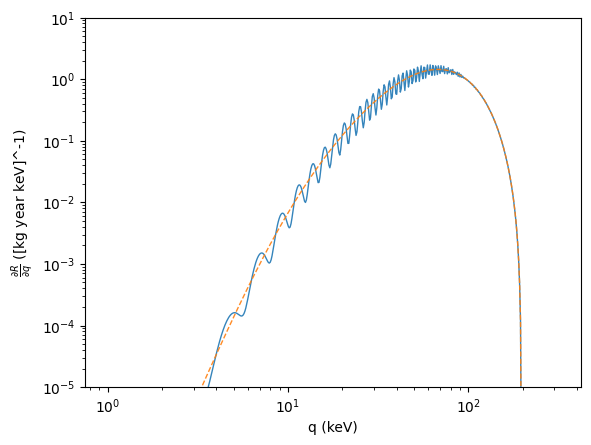

In [34]:
#Comparison of the total dR/dq
q_range = np.linspace(3,5.5,500)
q_range = 10**q_range
deriv_tot_2011 = [R_over_q_combo(q,mX, 30e-3, 1, NT, 1e-42, w0=30e-3) for q in q_range]
plt.plot(q_range/1000, deriv_combo*Screening(q_range), alpha=0.9, linewidth=1)
plt.plot(q_range/1000, deriv_tot_2011, alpha=0.9, linewidth=1, linestyle="dashed")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("q (keV)")
plt.ylabel(r"$\frac{\partial R}{\partial q}$ ([kg year keV]^-1)")
plt.ylim([1e-5,10])
plt.show()

In [35]:
#Rough estimation of the scattering rates for both for parameters given in the 2011 paper
print(sum([deriv_combo[i]*(q_range[i]-q_range[i-1])*Screening(q_range[i]) for i in range(1,len(q_range))]))
print(sum([deriv_tot_2011[i]*(q_range[i]-q_range[i-1]) for i in range(1,len(q_range))]))

106920.12017120153
107280.16685178937


The inverse mean function is only nonzero when $v_{min}<v_{esc}+v_E$.  Plugging in $v_{min}=\frac{\omega}{q}+\frac{q}{2m_\chi}$ and solving the quadratic, we get the following boundary: $m_\chi(v_{esc}+v_E)-\sqrt{m_\chi^2(v_{esc}+v_E)^2-2m_\chi \omega}<q<m_\chi(v_{esc}+v_E)+\sqrt{m_\chi^2(v_{esc}+v_E)^2-2m_\chi \omega}$

The largest boundary occurs when the energy equals $\omega_+$

# Differential energy spectrum
How does the scattering rate depend on energy?

In [36]:
"""
Gives the differential energy spectrum
@params:
    w: current energy transfer
    m_chi: mass of dark matter
    n: principal phonon mode
    j: phonon mode number
    sigma: cross sectional area
    A: coupling constant
    V: volume of crystal
    a: lattice spacing
"""

def dR_dw_n_j(w, m_chi, n,j, sigma=1, A=f, V=(a_Si**3)/4, a=a_Si):
    root = m_chi**2*(v_esc+v_E)**2-2*m_chi*w
    if root<=0:
        return 0
    bounds = [(m_chi*(v_esc+v_E)-np.sqrt(root)), 
          (m_chi*(v_esc+v_E)+np.sqrt(root))]
    integral = scipy.integrate.nquad(R_deriv_q_onePhonon, [bounds], args=(m_chi, n, j, sigma, A, V, a))[0]
    return integral

In [37]:
#def R_deriv_q_diag_n(q, m_chi, n,j, sigma=1, A=f, V=a_Si, a=a_Si): 
def dR_dw_n_j_diag(w, m_chi, n,j, sigma=1, A=f, V=(a_Si**3)/4, a=a_Si):
    root = m_chi**2*(v_esc+v_E)**2-2*m_chi*w
    if root<=0:
        return 0
    bounds = [(m_chi*(v_esc+v_E)-np.sqrt(root)), 
          (m_chi*(v_esc+v_E)+np.sqrt(root))]
    integral = scipy.integrate.nquad(R_deriv_q_diag_n, [bounds], args=(m_chi, n, j, sigma, A, V, a))[0]
    return integral

dR/dw for different masses


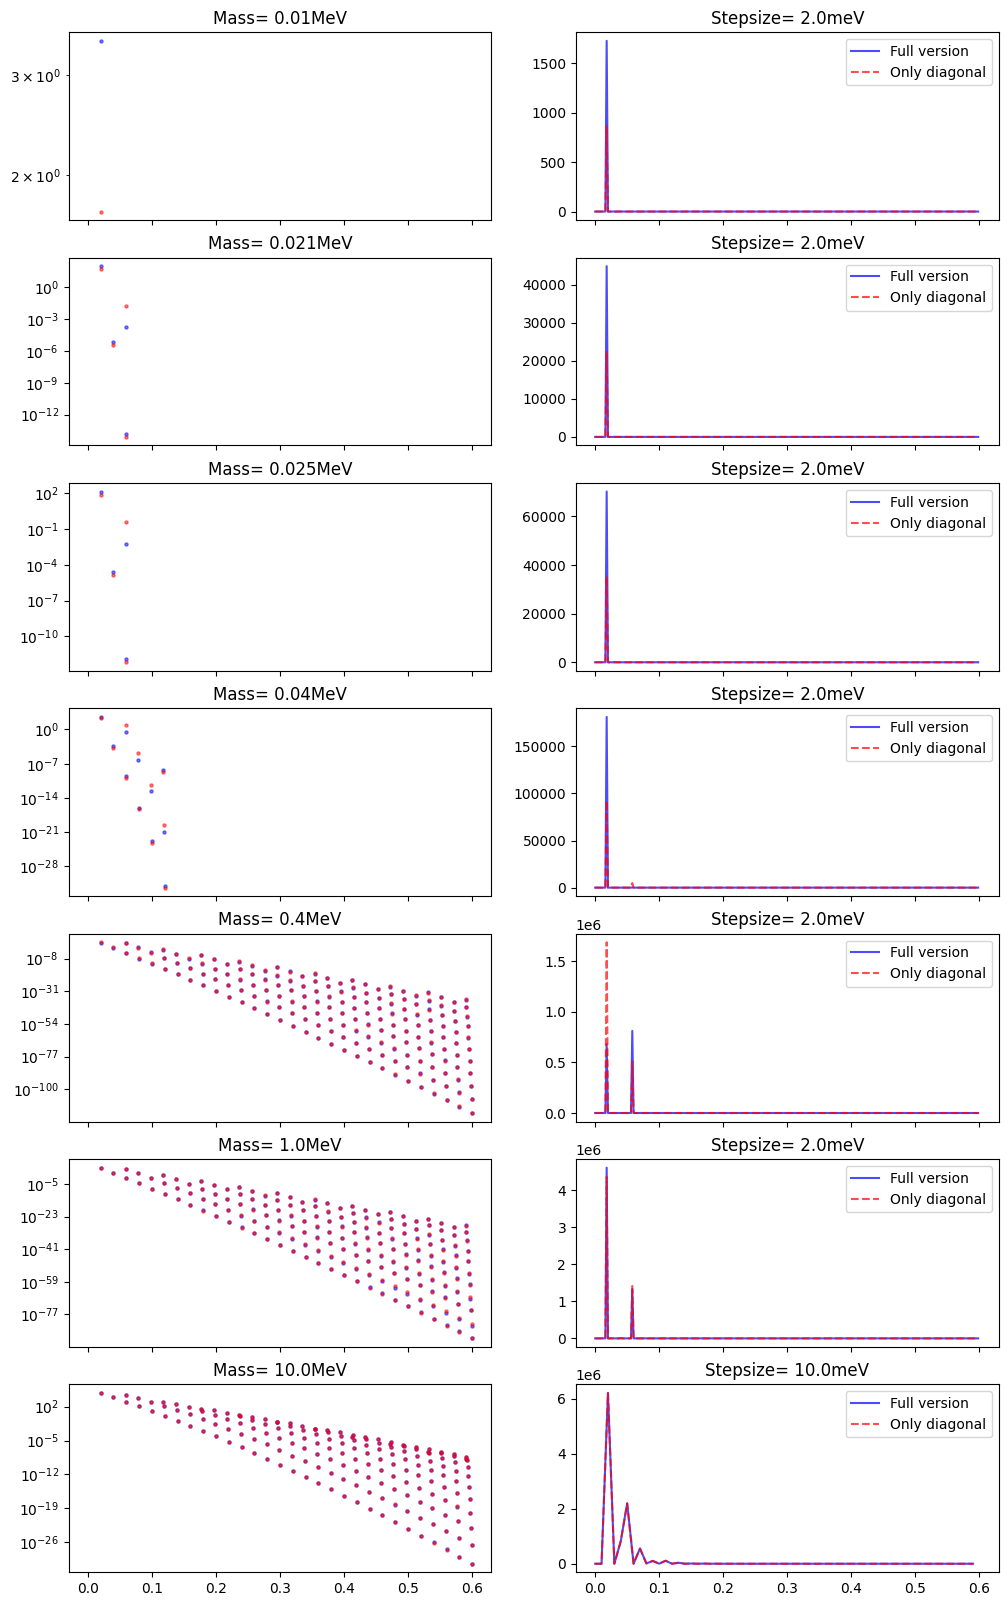

In [38]:
#Graphing dR/dw

mX = [10e3, 21e3, 25e3, 40e3, 4e5, 1e6, 1e7]
cross=1e-42
w_max = 0.6

fig, axes = plt.subplots(len(mX), 2, sharex=True, figsize=(12,20))

for m_ind in range(len(mX)):
    #Find each point
    w_list =[]
    dR_dw_list = []
    dR_dw_diag = []
    for n in range(1,int(w_max/w_plus)+1):
        for j in range(max([0, math.ceil((n*w_minus-w_max)/(w_minus-w_plus))]),n+1):
            w_current = j*w_plus+(n-j)*w_minus
            w_list.append(w_current)
            dR_dw_list.append(dR_dw_n_j(w_current, mX[m_ind], n, j, cross))
            dR_dw_diag.append(dR_dw_n_j_diag(w_current, mX[m_ind], n, j, cross))
            if w_current>w_max:print(str(n)+" "+str(j)+"\tMass: "+str(mass)) #should not print anything
    ordered = np.argsort(w_list)
    w_list = np.array(w_list)[ordered]
    dR_dw_list = np.array(dR_dw_list)[ordered]
    dR_dw_diag = np.array(dR_dw_diag)[ordered]
    #Graphing points
    #axes[m_ind, 0].vlines([20e-3, 50e-3])
    axes[m_ind, 0].scatter(w_list, dR_dw_list, s=5, alpha=0.5, color="b")
    axes[m_ind, 0].scatter(w_list, dR_dw_diag, s=5, alpha=0.5, color="r")
    axes[m_ind, 0].ticklabel_format(scilimits=(-2,1))
    axes[m_ind, 0].set_title("Mass= "+str(mX[m_ind]/1e6)+"MeV")
    
    
    axes[m_ind, 0].set_yscale("log")
    #Binned results
    if mX[m_ind]<=4e6:
        stepsize = 2e-3
    else:
        stepsize=1e-2
    w_values = np.arange(0, w_max, stepsize)
    y = []
    y_diag = []
    ind = 0

    for w in w_values:
        height1 = 0
        height2=0
        while w_list[ind]<w+stepsize:
            height1+=dR_dw_list[ind]
            height2+=dR_dw_diag[ind]
            ind+=1
            if ind>len(w_list)-1:
                break
        y.append(height1/stepsize)
        y_diag.append(height2/stepsize)
    
    axes[m_ind, 1].plot(w_values, y, color="blue", alpha=0.7, label="Full version")
    axes[m_ind, 1].plot(w_values, y_diag, linestyle="dashed", color="red", alpha=0.7, label="Only diagonal")
    axes[m_ind, 1].legend()
    axes[m_ind, 1].set_title("Stepsize= "+str(stepsize*1e3)+"meV")

print("dR/dw for different masses")

# Cross-section

In [39]:
"""
Gives the cross-sectional area necessary to get a certain rate
@params:
    R_q_func: the dR/dq function to be integrated
    params: the other parameters to input into R_q_func.  
        The order should go: (dark matter mass, minimum energy, maximum energy, all other parameters)
    wmin: the minimum energy of the system
    rate: scattering rate
"""
def cross_Sect(R_q_func, params, rate=3):
    m_chi = params[0]
    wmin=params[1]
    root = m_chi**2*(v_esc+v_E)**2-2*m_chi*wmin
    if root<=0:
        return None
    bounds = [(m_chi*(v_esc+v_E)-np.sqrt(root)), 
          (m_chi*(v_esc+v_E)+np.sqrt(root))]
    focus=(m_chi*(v_esc+v_E)-np.sqrt(root)/5, m_chi*(v_esc+v_E), m_chi*(v_esc+v_E)+np.sqrt(root)/5)
    integral = scipy.integrate.quad(R_q_func, bounds[0], bounds[1], args=params, points=focus, limit=100)[0]
    if integral==0:
        return None
    return rate/integral

In [40]:
#Finds the cross section for the screened scattering rate with a minimum energy of 20meV
starttime = time.time()
mass_range = 10**np.linspace(1, 9.5, 200) #in eV
cr1=[]
cr1 = np.array([cross_Sect(R_q_func_screen, (m, 20e-3, 0.5, 1, f, (a_Si**3)/4, a_Si)) for m in mass_range])
print(time.time()-starttime)

KeyboardInterrupt: 

In [ ]:
#Finds the cross section based on the 2011 paper for the screened scattering rate with a minimum energy of 20meV
starttime = time.time()
cr_2011 = [cross_Sect(R_over_q_combo, (m, 20e-3, 0.5, NT,1, 30e-3)) for m in mass_range]
print(time.time()-starttime)

2.291794538497925


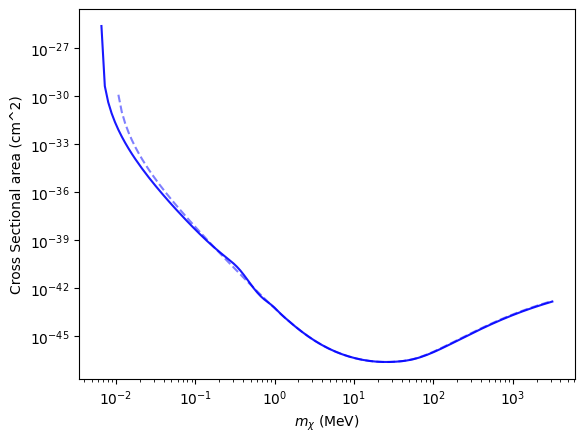

In [ ]:
#Graph of our cross-section vs cross section from 2011 paper for a minimum energy of 20meV
plt.plot(mass_range/1e6, cr1, color="blue", alpha=0.9)
plt.plot(mass_range/1e6, cr_2011, color="blue", linestyle="dashed", alpha=0.5)
plt.yscale("log")
plt.xscale("log")

plt.xlabel(r"$m_\chi$ (MeV)")
plt.ylabel("Cross Sectional area (cm^2)")
#plt.xlim([1, 1e3])
plt.show()

In [ ]:
#Screened cross-section calculations for a minimum of 60meV
starttime = time.time()
cr2_2011 = [cross_Sect(R_over_q_combo, (m, 60e-3, 0.5, NT,1, 30e-3)) for m in mass_range]
cr2 = [cross_Sect(R_q_func_screen, (m, 60e-3, 0.5, 1, f, (a_Si**3)/4, a_Si)) for m in mass_range]
print(time.time()-starttime)

254.65456223487854


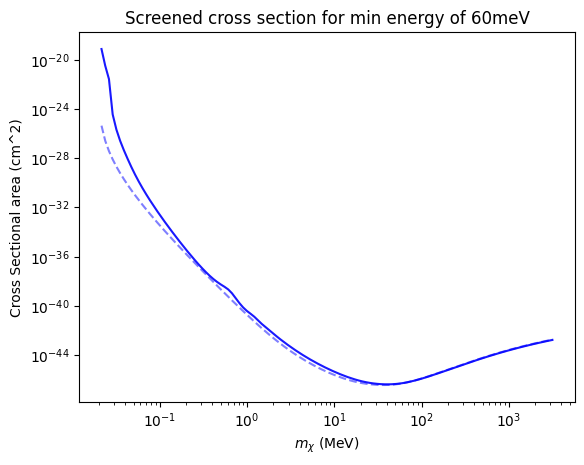

In [ ]:
plt.plot(mass_range/1e6, cr2, color="blue", alpha=0.9)
plt.plot(mass_range/1e6, cr2_2011, color="blue", linestyle="dashed", alpha=0.5)
plt.yscale("log")
plt.xscale("log")

plt.xlabel(r"$m_\chi$ (MeV)")
plt.ylabel("Cross Sectional area (cm^2)")
plt.title("Screened cross section for min energy of 60meV")
plt.show()

In [ ]:
#Screened cross-section calculations for a minimum of 1eV
starttime = time.time()
cr3_2011 = [cross_Sect(R_over_q_combo, (m, 1, 1.2, NT,1, 30e-3)) for m in mass_range]
cr3 = [cross_Sect(R_q_func_screen, (m, 1, 1.2, 1, f, (a_Si**3)/4, a_Si)) for m in mass_range]
print(time.time()-starttime)

176.0656681060791


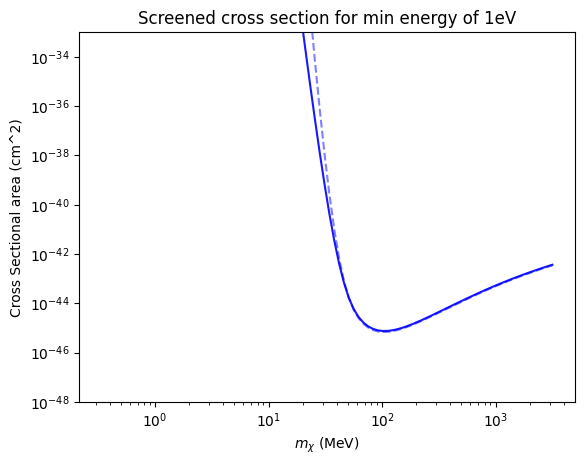

In [ ]:
plt.plot(mass_range/1e6, cr3, color="blue", alpha=0.9)
plt.plot(mass_range/1e6, cr3_2011, color="blue", linestyle="dashed", alpha=0.5)
plt.yscale("log")
plt.xscale("log")

plt.xlabel(r"$m_\chi$ (MeV)")
plt.ylabel("Cross Sectional area (cm^2)")
plt.title("Screened cross section for min energy of 1eV")
plt.ylim([1e-48, 1e-33])
plt.show()

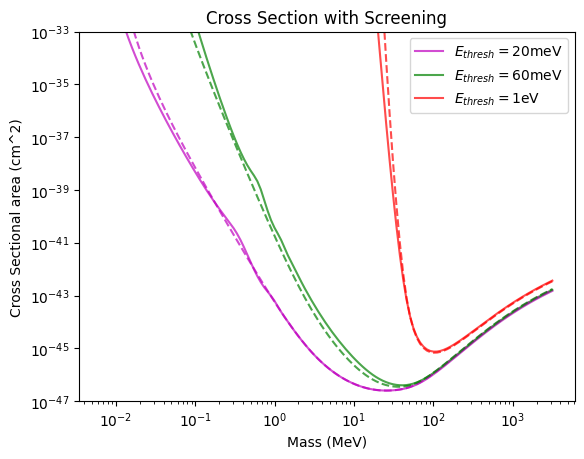

In [ ]:
plt.plot(mass_range/1e6, cr1, color="m", alpha=0.7, label=r"$E_{thresh}=20$meV")
plt.plot(mass_range/1e6, cr2, color="g", alpha=0.7, label=r"$E_{thresh}=60$meV")
plt.plot(mass_range/1e6, cr3, color="r", alpha=0.7, label=r"$E_{thresh}=1$eV")

plt.plot(mass_range/1e6, cr_2011, color="m", alpha=0.7, linestyle="dashed")
plt.plot(mass_range/1e6, cr2_2011, color="g", alpha=0.7, linestyle="dashed")
plt.plot(mass_range/1e6, cr3_2011, color="r", alpha=0.7, linestyle="dashed")

plt.yscale("log")
plt.xscale("log")
plt.xlabel("Mass (MeV)")
plt.ylabel("Cross Sectional area (cm^2)")
plt.ylim([1e-47, 1e-33])
plt.title("Cross Section with Screening")
plt.legend()
plt.show()

In [ ]:
#Create the cross sections with no screening for full version and incoherent approximation
starttime = time.time()
energies = [19.9e-3, 50e-3, 60e-3, 1]
cr_noscreen = [[cross_Sect(R_deriv_q_combo, (m, w, max([0.5, w+0.2]))) for m in mass_range] for w in energies]
cr_noscreen_diag = [[cross_Sect(Rdiag_deriv_q_combo, (m, w, max([0.5, w+0.2]))) for m in mass_range] for w in energies]
print(time.time()-starttime)

1215.1224315166473


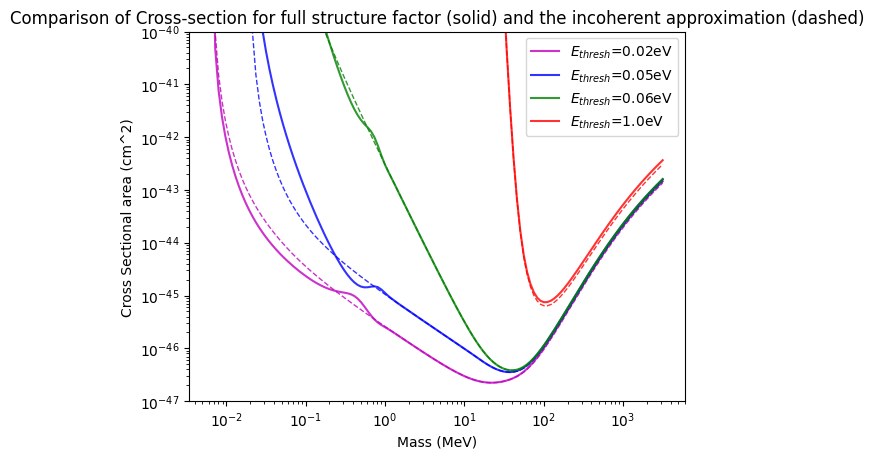

In [ ]:
coloring = ["m", "b", "g", "r"]
for energy, c_val, full, diagonal in zip(energies, coloring, cr_noscreen, cr_noscreen_diag):
    plt.plot(mass_range/1e6, full, color=c_val, label=r"$E_{thresh}$="+str(math.ceil(1000*energy)/1000)+"eV", linewidth=1.5, alpha=0.8)
    plt.plot(mass_range/1e6, diagonal, color=c_val, linewidth=1, linestyle="dashed", alpha=0.8)

plt.yscale("log")
plt.xscale("log")
plt.xlabel("Mass (MeV)")
plt.ylabel("Cross Sectional area (cm^2)")
plt.ylim([1e-47, 1e-40])
plt.title("Comparison of Cross-section for full structure factor (solid) and the incoherent approximation (dashed)")
plt.legend()
plt.show()

In [ ]:
#Calculation of cross section for narrower region
mass_range = 10**np.linspace(3, 7, 300)
starttime = time.time()
energies = [20e-3, 50e-3, 60e-3, 1]
cr_noscreen = [[cross_Sect(R_deriv_q_combo, (m, w, max([0.5, w+0.2]))) for m in mass_range] for w in energies]
cr_noscreen_diag = [[cross_Sect(Rdiag_deriv_q_combo, (m, w, max([0.5, w+0.2]))) for m in mass_range] for w in energies]
print(time.time()-starttime)

511.31103014945984


In [ ]:
#Find the ratio of diagonal over full cross section (should be equivalent to full scattering rate over diagonal scattering rate)
cr_ratio = []
for w_ind in range(len(energies)):
    cr_curr_ratio = []
    for ind_2 in range(len(cr_noscreen[0])):
        if cr_noscreen[w_ind][ind_2]==None or cr_noscreen_diag[w_ind][ind_2]==None:
            cr_curr_ratio.append(None)
        #else: cr_curr_ratio.append(cr_noscreen[w_ind][ind_2]/cr_noscreen_diag[w_ind][ind_2])
        else: cr_curr_ratio.append(cr_noscreen_diag[w_ind][ind_2]/cr_noscreen[w_ind][ind_2])
    cr_ratio.append(cr_curr_ratio)

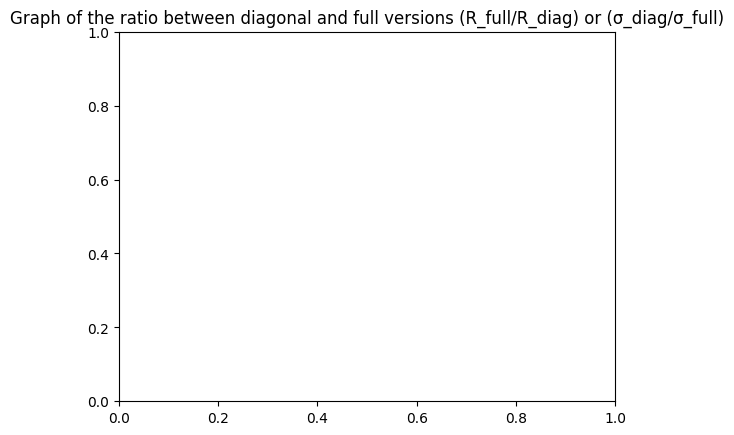

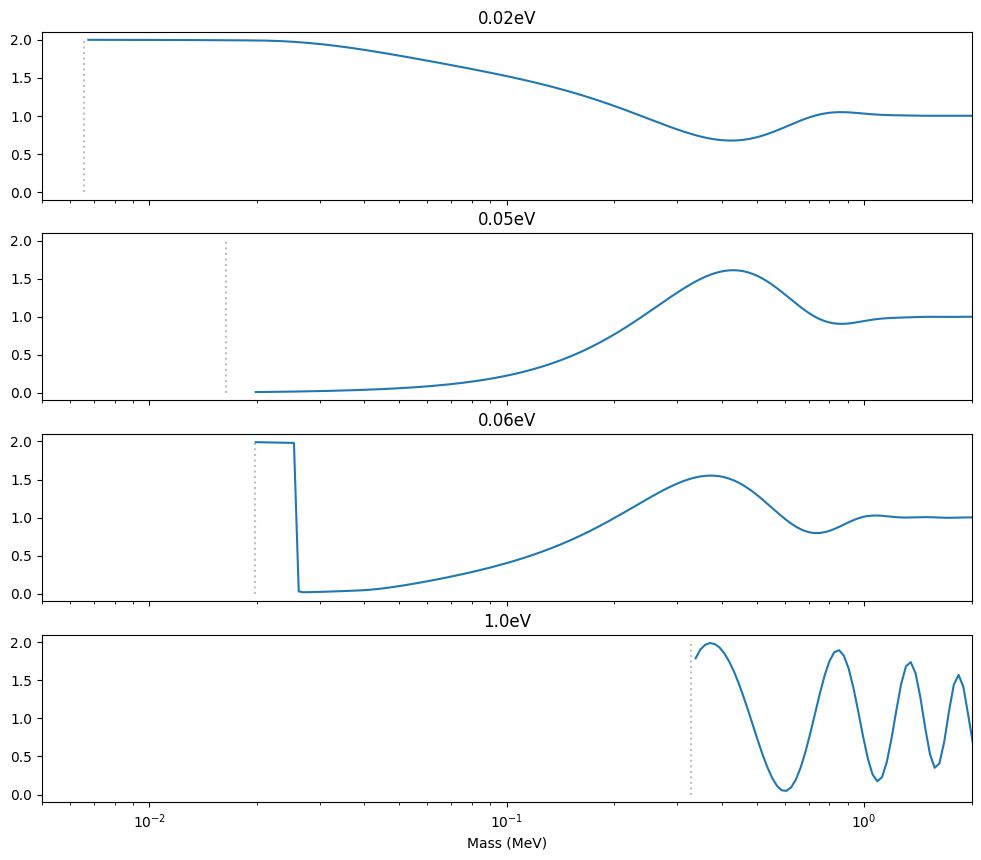

In [ ]:
plt.title("Graph of the ratio between diagonal and full versions (R_full/R_diag) or (σ_diag/σ_full)")
fig, axes= plt.subplots(len(energies), sharex=True, figsize=(12,10))
for w_ind in range(len(energies)):
    axes[w_ind].plot(mass_range/1e6, cr_ratio[w_ind])
    axes[w_ind].set_xscale('log')
    axes[w_ind].set_xlim([5e-3,2])
    axes[w_ind].set_title(str(math.ceil(energies[w_ind]*1e3)/1e3)+"eV")
    axes[w_ind].vlines([2*energies[w_ind]/(v_val**2*1e6)], 0,2, color="grey", alpha=0.5, linestyle="dotted")
plt.xlabel("Mass (MeV)")
plt.show()

There appears to be a step function for the 60meV version.  There are enough datapoints that the drop should be considered notable.  Currently, 60meV is just above the w_minus of 59meV. 

The gap at 50meV between the calculated minimum mass and the actual start of the graph is likely due to the fact that the phonon with the lowest detected energy is not equal to the minimum energy of 50meV, but instead the next energy level of 59meV.

In [ ]:
w_curr = 60.1e-3
for n in range(1,int(w_curr/w_plus)+1):
    for j in range(max([0, math.ceil((n*w_minus-w_max)/(w_minus-w_plus))]),n+1):
        if j*w_plus+(n-j)*w_minus<w_curr: print("n="+str(n)+"\t j="+str(j))

n=1	 j=0
n=1	 j=1
n=2	 j=2
n=3	 j=3


In [ ]:
#Analysis of the w=w_minus threshold region
mass_range = 10**np.linspace(4.2, 6, 300)
starttime = time.time()
energies = [58.9e-3, 59.1e-3, 59.9e-3, 60.1e-3]
cr_noscreen = [[cross_Sect(R_deriv_q_combo, (m, w, max([0.5, w+0.2]))) for m in mass_range] for w in energies]
cr_noscreen_diag = [[cross_Sect(Rdiag_deriv_q_combo, (m, w, max([0.5, w+0.2]))) for m in mass_range] for w in energies]
cr_ratio = []
for w_ind in range(len(energies)):
    cr_curr_ratio = []
    for ind_2 in range(len(cr_noscreen[0])):
        if cr_noscreen[w_ind][ind_2]==None or cr_noscreen_diag[w_ind][ind_2]==None:
            cr_curr_ratio.append(None)
        else: cr_curr_ratio.append(cr_noscreen_diag[w_ind][ind_2]/cr_noscreen[w_ind][ind_2])
    cr_ratio.append(cr_curr_ratio)
print(time.time()-starttime)

706.2202951908112


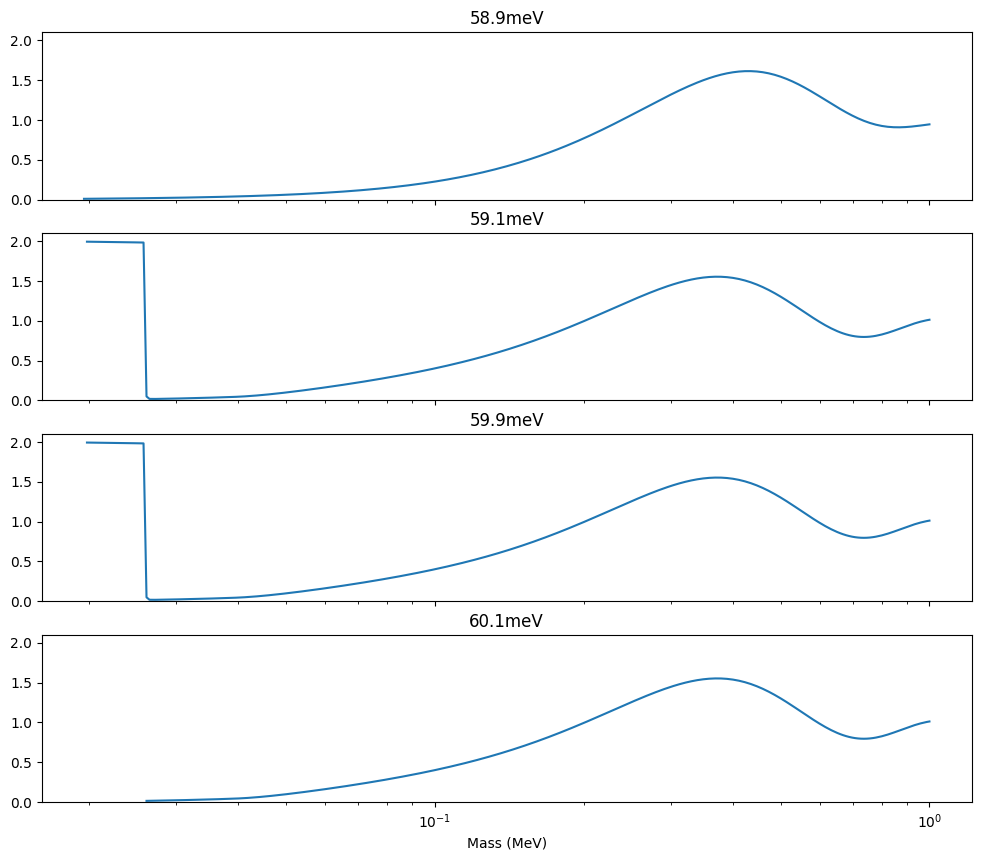

In [ ]:
fig, axes= plt.subplots(len(energies), sharex=True, figsize=(12,10))
for w_ind in range(len(energies)):
    axes[w_ind].plot(mass_range/1e6, cr_ratio[w_ind])
    axes[w_ind].set_xscale('log')
    axes[w_ind].set_title(str(math.ceil(energies[w_ind]*1e4)/10)+"meV")
    axes[w_ind].set_ylim([0,2.1])
plt.xlabel("Mass (MeV)")
plt.show()

Under w_plus, the excluded phonons are n=1/j=1 and n=2/j=2.  After w_plus, n=1/j=0 is excluded.  Finally, after 60meV, n=3/j=3 is excluded.  Thus, the phonons of focus are n=1/j=0 and n=3/j=3.  The step function appears to be between these two phonon's mass cutoffs

# Class Creation (ignore)

In [ ]:
class TwoSiteScattering:
    def __init__(self, m_chi, cross_section, A, V, w1, w2, m_targ, lattice_spacing):
        self.mX = m_chi
        self.sig = cross_section
        self.A = A
        self.V = V
        self.w1 = w1
        self.w2 = w2
        self.m_targ = m_targ
        self.a=lattice_spacing

    """
    The Debye-Waller function for a two-site lattice
    @params 
        q: the momentum transfer from dark matter to the crystal
    """
    def debye_waller(self, q):
        return q**2/(8*self.m_targ)*(1/self.w1+1/self.w2)
    
    
    """
    The diagonal terms (without the delta function) for one n,j combination
    @params
        q: the momentum transfer from dark matter to the crystal
        w1, w2: energy levels of the element
        n: principle phonon number
        j: phonon mode number
    """
    def diagonal_C_true(self, q, n, j):
        expDebyeWaller = np.exp(-2*self.debye_waller(q))
        c=expDebyeWaller/self.V * (q**2/(4*self.m_targ))**n * 2*np.pi/(factorial(j)*factorial(n-j)*self.w1**j*self.w2**(n-j))
        return c
    
    """
    The off-diagonal terms (without the delta function) for one n,j combination
    @params
        q: the momentum transfer from dark matter to the crystal
        n: principle phonon number
        j: phonon mode number
    """
    def offDiagonal_C_true(self, q, n, j):
        expDebyeWaller = np.exp(-2*self.debye_waller(q, self.m_targ, self.w1, self.w2))
        c=expDebyeWaller/self.V * (q**2/(4*self.m_targ))**n * 2*np.pi/(factorial(j)*factorial(n-j)*self.w1**j*self.w2**(n-j))
        if (n-j)%2==1:
            c = -c
        c = c*np.cos(q*self.a)
        return c

    """
    Structure Factor for one n and j pair, integrated with omega to remove the delta function
    @params
        q: the momentum transfer from dark matter to the crystal
        n: principle phonon number
        j: phonon mode number
    """
    def StructureFactor_n_j(self,q,n, j):
        return 2*self.A**2*(self.diagonal_C_true(q, n, j)
                          +self.offDiagonal_C_true(q, n, j))
    
    """
    Structure Factor for one n, integrated with omega to remove the delta function
    @params
        q: the momentum transfer from dark matter to the crystal
        n: principle phonon number
    """
    def StructureFactor_n(self,q, n):
        return sum([2*self.A**2*(self.diagonal_C_true(q, n, j)
                            +self.offDiagonal_C_true(q, n, j)) for j in range(n+1)] )